In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_from_disk
from pipeline import get_dataloaders
from config import Config

## Load Dataset

In [3]:
import zipfile
import os

!unzip parallel_en_fr_corpus
!unzip tokenizer_en
!unzip tokenizer_fr


Archive:  parallel_en_fr_corpus.zip
   creating: parallel_en_fr_corpus/
  inflating: parallel_en_fr_corpus/dataset_dict.json  
   creating: parallel_en_fr_corpus/test/
   creating: parallel_en_fr_corpus/train/
   creating: parallel_en_fr_corpus/validation/
  inflating: parallel_en_fr_corpus/test/state.json  
  inflating: parallel_en_fr_corpus/test/dataset.arrow  
  inflating: parallel_en_fr_corpus/test/dataset_info.json  
  inflating: parallel_en_fr_corpus/train/state.json  
  inflating: parallel_en_fr_corpus/train/dataset.arrow  
  inflating: parallel_en_fr_corpus/train/dataset_info.json  
  inflating: parallel_en_fr_corpus/validation/state.json  
  inflating: parallel_en_fr_corpus/validation/dataset.arrow  
  inflating: parallel_en_fr_corpus/validation/dataset_info.json  
Archive:  tokenizer_en.zip
   creating: tokenizer_en/
  inflating: tokenizer_en/tokenizer_config.json  
  inflating: tokenizer_en/special_tokens_map.json  
  inflating: tokenizer_en/tokenizer.json  
Archive:  tokeni

In [4]:
dataset = load_from_disk("parallel_en_fr_corpus")

train_fr = [x["text_fr"] for x in dataset["train"]]
train_en = [x["text_en"] for x in dataset["train"]]
val_fr   = [x["text_fr"] for x in dataset["validation"]]
val_en   = [x["text_en"] for x in dataset["validation"]]
test_fr  = [x["text_fr"] for x in dataset["test"]]
test_en  = [x["text_en"] for x in dataset["test"]]

train_loader, val_loader, fr_tokenizer, en_tokenizer = get_dataloaders(
    train_fr=train_fr, train_en=train_en,
    val_fr=val_fr,     val_en=val_en,
    batch_size=32
)

test_loader, _, _, _ = get_dataloaders(
    train_fr=test_fr, train_en=test_en,
    val_fr=test_fr,   val_en=test_en,
    batch_size=32
)

## 1-Encoder (Bi-LSTM)

French sentence tokens → meaningful contextual vectors

concatenates hidden state of forward and backward pass

forward LSTM:512

backward LSTM:512

output concatenated:1024

`h_i = [h_forward_i ; h_backward_i]  ∈ R^{2h}`

In [5]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_size=256, hidden_size=512, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_size, padding_idx=Config.PAD_TOKEN_ID)
        self.lstm = nn.LSTM(
            input_size=embedding_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True,
            bidirectional=True
        )

    def forward(self, src):
        # src: [batch, src_len]
        # encoder_outputs: [batch, src_len, 2*hidden]  hidden/cell: [2*num_layers, batch, hidden]
        embedded = self.embedding(src) #get embedding vectors of tokens
        encoder_outputs, (hidden, cell) = self.lstm(embedded)
        return encoder_outputs, hidden, cell

## 2-Additive Attention

At each decoder step --> compare the current decoder hidden state with every encoder word

Decide which words the decoder state "attends to" --> context

`e_{t,i} = v^T tanh(W s_{t-1} + U h_i)`  
`α_{t,i} = softmax(e_{t,i})`  
`c_t = Σ α_{t,i} h_i`

In [6]:
class AdditiveAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.W = nn.Linear(hidden_size, hidden_size)       # transform decoder hidden state
        self.U = nn.Linear(hidden_size * 2, hidden_size)   # transform encoder outputs
        self.v = nn.Linear(hidden_size, 1, bias=False)     #single score

    def forward(self, decoder_hidden, encoder_outputs, src_mask):
        # decoder_hidden: [B, h]   encoder_outputs: [B, src_len, 2h]   src_mask: [B, src_len]
        src_len = encoder_outputs.size(1)
        dec = decoder_hidden.unsqueeze(1).expand(-1, src_len, -1)   # [B, src_len, h]
        scores = self.v(torch.tanh(self.W(dec) + self.U(encoder_outputs))).squeeze(-1)  # [B, src_len]
        scores = scores.masked_fill(src_mask == 0, -1e9) #set padding tokens to infinity --> zero after softmax
        weights = F.softmax(scores, dim=1) # [B, src_len]
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B, 2h]
        return context, weights

## 3-Decoder

generate English sentence one word at a time

previous English word + attention over French sentence → next English word

`s_t = LSTM([y_{t-1} ; c_t], s_{t-1})`  
`logits_t = W_out [s_t ; c_t ; y_{t-1}]`

In [7]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size=256, hidden_size=512, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=Config.PAD_TOKEN_ID)
        self.attention = AdditiveAttention(hidden_size)
        self.lstm = nn.LSTM(
            input_size=embed_size + hidden_size * 2, #prev word embedding + ct
            hidden_size=hidden_size,
            batch_first=True
        )
        #predict next word
        #input --> decoder o/p + context vector + prev word embedding
        self.fc_out = nn.Linear(hidden_size + hidden_size * 2 + embed_size, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def step(self, prev_token, hidden, cell, encoder_outputs, src_mask):
        # prev_token: [B]  →  embedded: [B, embed_size]
        embedded = self.dropout(self.embedding(prev_token))
        context, attn_weights = self.attention(hidden[-1], encoder_outputs, src_mask)
        lstm_input = torch.cat([embedded, context], dim=1).unsqueeze(1)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        logits = self.fc_out(torch.cat([output.squeeze(1), context, embedded], dim=1))
        return logits, hidden, cell, attn_weights

## 4-Seq2Seq Model

In [8]:
class LSTMSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, hidden_size=512):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        # s0 = tanh(W_init [h_fwd ; h_bwd])
        self.init_hidden = nn.Linear(hidden_size * 2, hidden_size)

    def _init_decoder_state(self, enc_hidden):
        # enc_hidden: [2, B, h]  (forward=[-2], backward=[-1])
        h0 = torch.tanh(self.init_hidden(
            torch.cat([enc_hidden[-2], enc_hidden[-1]], dim=1)
        )).unsqueeze(0)                    # [1, B, h]
        c0 = torch.zeros_like(h0)         # cell starts at zero
        return h0, c0

    def forward(self, src, tgt, teacher_forcing_ratio=0.5, src_mask=None):
        B, tgt_len = tgt.size()
        vocab_size  = self.decoder.fc_out.out_features

        if src_mask is None:
            src_mask = (src != Config.PAD_TOKEN_ID)

        enc_out, enc_h, enc_c = self.encoder(src)
        hidden, cell = self._init_decoder_state(enc_h)

        outputs = torch.zeros(B, tgt_len, vocab_size, device=src.device)
        prev_token = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, cell, _ = self.decoder.step(prev_token, hidden, cell, enc_out, src_mask)
            outputs[:, t] = logits
            use_tf = torch.rand(1).item() < teacher_forcing_ratio
            prev_token = tgt[:, t] if use_tf else logits.argmax(dim=1)

        return outputs

## 5-Training & Evaluation

In [9]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        src      = batch["src"].to(device)
        tgt      = batch["tgt"].to(device)
        src_mask = batch["src_padding_mask"].to(device)

        optimizer.zero_grad()
        outputs = model(src, tgt, teacher_forcing_ratio=0.5, src_mask=src_mask)

        # skip BOS position, flatten for CE
        loss = criterion(outputs[:, 1:].reshape(-1, outputs.size(-1)), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            src      = batch["src"].to(device)
            tgt      = batch["tgt"].to(device)
            src_mask = batch["src_padding_mask"].to(device)
            outputs  = model(src, tgt, teacher_forcing_ratio=0.0, src_mask=src_mask)
            loss = criterion(outputs[:, 1:].reshape(-1, outputs.size(-1)), tgt[:, 1:].reshape(-1))
            total_loss += loss.item()
    return total_loss / len(loader)

## 6-Beam Search

In [10]:
def beam_search(model, src_sentence, fr_tokenizer, beam_width=4, max_len=32):
    """Returns best token-id sequence (excluding BOS) and all attention tensors."""
    model.eval()
    device = next(model.parameters()).device

    # --- encode source ---
    tokens = [Config.BOS_TOKEN_ID] + fr_tokenizer.encode(src_sentence) + [Config.EOS_TOKEN_ID]
    tokens = tokens[:Config.MAX_SEQ_LEN]
    src      = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)  # [1, src_len]
    src_mask = (src != Config.PAD_TOKEN_ID)

    with torch.no_grad():
        enc_out, enc_h, _ = model.encoder(src)
        h0, c0 = model._init_decoder_state(enc_h)

    # Each beam: (log_prob, token_ids, hidden, cell, attentions)
    beams = [(0.0, [Config.BOS_TOKEN_ID], h0, c0, [])]
    completed = []

    with torch.no_grad():
        for _ in range(max_len):
            candidates = []
            for log_prob, ids, hidden, cell, attns in beams:
                if ids[-1] == Config.EOS_TOKEN_ID:
                    completed.append((log_prob, ids, attns))
                    continue
                prev = torch.tensor([ids[-1]], dtype=torch.long, device=device)
                logits, new_h, new_c, attn = model.decoder.step(
                    prev, hidden, cell, enc_out, src_mask
                )
                log_probs = F.log_softmax(logits, dim=-1).squeeze(0)  # [vocab]
                topk_lp, topk_ids = log_probs.topk(beam_width)
                for lp, tid in zip(topk_lp.tolist(), topk_ids.tolist()):
                    candidates.append((
                        log_prob + lp,
                        ids + [tid],
                        new_h, new_c,
                        attns + [attn.squeeze(0).cpu()]
                    ))

            if not candidates:
                break
            beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:beam_width]

    # gather any unfinished beams
    for log_prob, ids, hidden, cell, attns in beams:
        completed.append((log_prob, ids, attns))

    best_log_prob, best_ids, best_attns = max(completed, key=lambda x: x[0])

    # strip BOS/EOS
    result_ids = [i for i in best_ids[1:] if i != Config.EOS_TOKEN_ID]
    return result_ids, best_attns, tokens

## 7-BLEU Score

In [11]:
from collections import Counter
import math

def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))

def corpus_bleu(hypotheses, references, max_n=4):
    """
    hypotheses: list of token-id lists
    references: list of token-id lists
    """
    clipped_counts = [0] * max_n
    total_counts   = [0] * max_n
    hyp_len = ref_len = 0

    for hyp, ref in zip(hypotheses, references):
        hyp_len += len(hyp)
        ref_len += len(ref)
        for n in range(1, max_n + 1):
            h_counts = ngram_counts(hyp, n)
            r_counts = ngram_counts(ref, n)
            clipped  = {ng: min(c, r_counts[ng]) for ng, c in h_counts.items()}
            clipped_counts[n-1] += sum(clipped.values())
            total_counts[n-1]   += sum(h_counts.values())

    precisions = [
        math.log(c / t) if t > 0 and c > 0 else -float("inf")
        for c, t in zip(clipped_counts, total_counts)
    ]
    bp = min(1.0, math.exp(1 - ref_len / hyp_len)) if hyp_len > 0 else 0
    bleu = bp * math.exp(sum(precisions) / max_n)
    return bleu * 100


def compute_test_bleu(model, test_fr, test_en, fr_tokenizer, en_tokenizer,
                      beam_width=4, max_len=32):
    hypotheses, references = [], []
    for src_sent, ref_sent in zip(test_fr, test_en):
        hyp_ids, _, _ = beam_search(model, src_sent, fr_tokenizer, beam_width, max_len)
        ref_ids = en_tokenizer.encode(ref_sent)
        hypotheses.append(hyp_ids)
        references.append(ref_ids)

    return corpus_bleu(hypotheses, references)

## 8 — Attention Visualization

In [12]:
def plot_attention(attentions, src_tokens, tgt_tokens):
    matrix = torch.stack(attentions).numpy()  # [tgt_len, src_len]
    fig, ax = plt.subplots(figsize=(max(8, len(src_tokens)), max(4, len(tgt_tokens) // 2)))
    im = ax.imshow(matrix, aspect="auto", cmap="Blues")
    ax.set_xticks(range(len(src_tokens))); ax.set_xticklabels(src_tokens, rotation=45, ha="right")
    ax.set_yticks(range(len(tgt_tokens))); ax.set_yticklabels(tgt_tokens)
    ax.set_xlabel("French input tokens")
    ax.set_ylabel("English output tokens")
    ax.set_title("LSTM Additive Attention")
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## 9-Checkpoint Utilities

In [13]:
def save_checkpoint(model, optimizer, epoch, path="lstm_checkpoint.pt"):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }, path)

def load_checkpoint(model, optimizer, path="lstm_checkpoint.pt", device="cpu"):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    return ckpt["epoch"]

## 10-Create Model

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(vocab_size=len(fr_tokenizer), embedding_size=256, hidden_size=512, num_layers=1, dropout=0.3)
decoder = Decoder(vocab_size=len(en_tokenizer), embed_size=256, hidden_size=512, dropout=0.3)
model   = LSTMSeq2Seq(encoder, decoder, hidden_size=512).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=Config.PAD_TOKEN_ID)

## 11-Train

In [15]:
CHECKPOINT = "lstm_checkpoint.pt"
best_val_loss = float("inf")

for epoch in range(1, 11):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss   = evaluate_epoch(model, val_loader, criterion, device)
    print(f"Epoch {epoch:2d}/10  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}", end="")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        save_checkpoint(model, optimizer, epoch, CHECKPOINT)
        print(" saved model")
    else:
        print()

Epoch  1/10  Train Loss: 2.3562  Val Loss: 1.7656 saved model
Epoch  2/10  Train Loss: 1.2149  Val Loss: 1.4034 saved model
Epoch  3/10  Train Loss: 0.6396  Val Loss: 1.2864 saved model
Epoch  4/10  Train Loss: 0.3570  Val Loss: 1.3458
Epoch  5/10  Train Loss: 0.2412  Val Loss: 1.3029
Epoch  6/10  Train Loss: 0.1598  Val Loss: 1.3991
Epoch  7/10  Train Loss: 0.1304  Val Loss: 1.4264
Epoch  8/10  Train Loss: 0.1058  Val Loss: 1.4719
Epoch  9/10  Train Loss: 0.0941  Val Loss: 1.4717
Epoch 10/10  Train Loss: 0.0846  Val Loss: 1.4755


## 12-Evaluate on Test Set (BLEU)

In [16]:
# Load best checkpoint before evaluating
loaded_epoch = load_checkpoint(model, optimizer, CHECKPOINT, device)
print(f"Loaded checkpoint from epoch {loaded_epoch}")

bleu = compute_test_bleu(model, test_fr, test_en, fr_tokenizer, en_tokenizer, beam_width=3, max_len=32)
print(f"Test BLEU: {bleu:.2f}")

Loaded checkpoint from epoch 3
Test BLEU: 48.32


## 13-Translate Examples & Attention Heatmap

French:    je suis serieux .
Reference: i m not bluffing .
Model:     <s> ▁i ▁m ▁serious ▁.


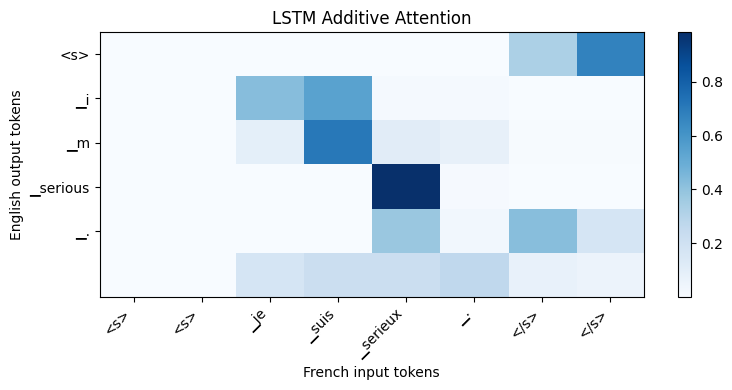

French:    je ne suis pas ton ennemi .
Reference: i am not your enemy .
Model:     <s> ▁i ▁m ▁not ▁your ▁enemy ▁.


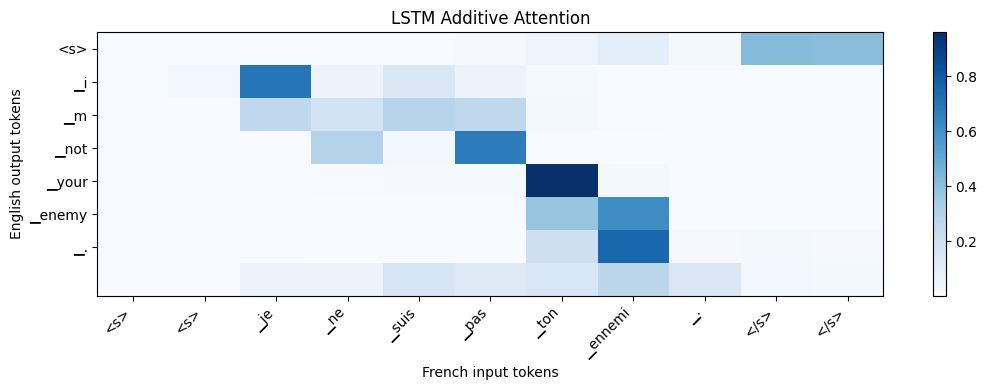

French:    c est ma camarade de classe .
Reference: she s my classmate .
Model:     <s> ▁he ▁is ▁my ▁classmate ▁.


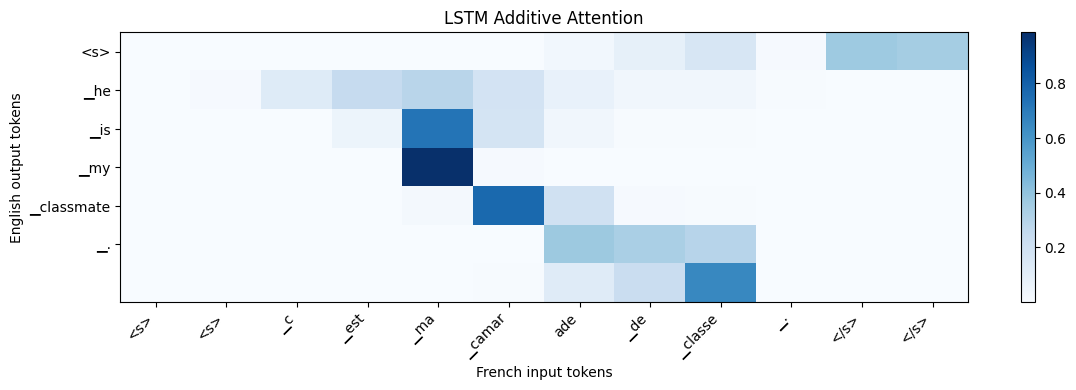

In [17]:
indices = [343,6,89]
for idx in indices:

    src_sentence = test_fr[idx]
    ref_sentence = test_en[idx]

    hyp_ids, attentions, src_token_ids = beam_search(
        model, src_sentence, fr_tokenizer, beam_width=4, max_len=32
    )

    translation = en_tokenizer.decode(hyp_ids)

    print(f"French:    {src_sentence}")
    print(f"Reference: {ref_sentence}")
    print(f"Model:     {translation}")

    src_tokens = fr_tokenizer.convert_ids_to_tokens(src_token_ids)
    tgt_tokens = en_tokenizer.convert_ids_to_tokens(hyp_ids)

    if attentions:
        plot_attention(attentions, src_tokens, tgt_tokens)

## 14-Live Test

Translation: <s> ▁i ▁m ▁serious ▁.


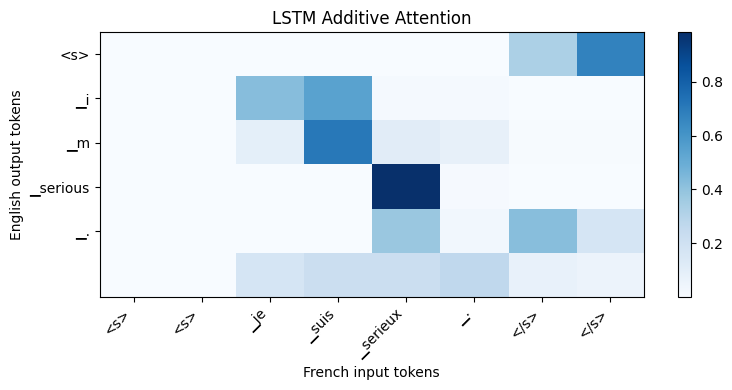

In [22]:
sentence = "je suis serieux ."

hyp_ids, attentions, src_token_ids = beam_search(
    model, sentence, fr_tokenizer, beam_width=3, max_len=32
)
print("Translation:", en_tokenizer.decode(hyp_ids))

if attentions:
    plot_attention(
        attentions,
        fr_tokenizer.convert_ids_to_tokens(src_token_ids),
        en_tokenizer.convert_ids_to_tokens(hyp_ids)
    )